# Laporan Simulasi Model Ising 2D

**Kelompok:** Balmond  
**Anggota:**  
1. Eki Permata Cahya Hati (01231007)  
2. Melky Juli Kurniawan Silalahi (01231010)  
3. Yustiara Sampe Manggoali (01231019)  

**Topik:** Kasus 1 - Fase Feromagnetik ($T = 1.0$)

---

### Pendahuluan
Pada simulasi ini, sistem magnetik disimulasikan pada suhu $T = 1.0$, yang berada di bawah suhu kritis teoritis ($T < T_c \approx 2.27$). 

**Tujuan:**
Mengamati perilaku *spin* individu yang berorientasi searah secara spontan untuk membentuk domain magnetik yang seragam. Dalam kondisi ini, diharapkan nilai mutlak magnetisasi rata-rata ($|M|$) akan mendekati 1, yang mengindikasikan sistem berada dalam fase feromagnetik.

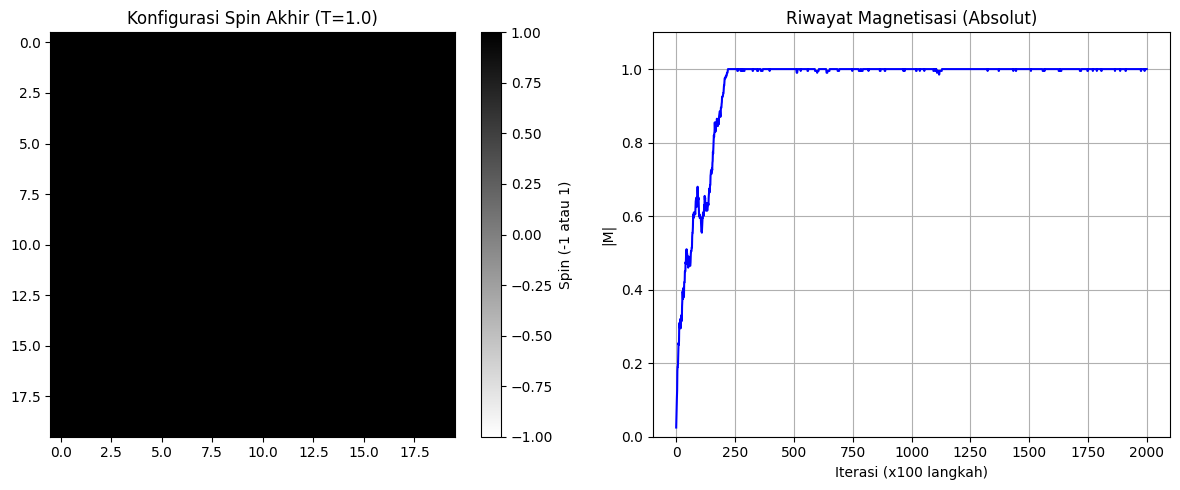

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameter Simulasi Kasus 1: Fase Feromagnetik ---
ukuran_kisi = 20
suhu = 1.0              # T < Tc (Fase Feromagnetik)
jumlah_langkah = 200000

# Mulai dengan membuat papan spin acak (Hot Start)
papan_spin = np.random.choice([-1, 1], size=(ukuran_kisi, ukuran_kisi))

# Wadah untuk mencatat perubahan magnetisasi
catatan_magnetisasi = []

# --- Fungsi Menghitung Energi Lokal (Delta E) ---
def hitung_perubahan_energi(kisi, i, j):
    spin = kisi[i, j]
    # Menggunakan kondisi batas periodik (periodic boundary conditions) dengan modulo
    atas = kisi[(i-1) % ukuran_kisi, j]
    bawah = kisi[(i+1) % ukuran_kisi, j]
    kiri = kisi[i, (j-1) % ukuran_kisi]
    kanan = kisi[i, (j+1) % ukuran_kisi]

    total_tetangga = atas + bawah + kiri + kanan
    # Rumus Delta E untuk flip satu spin pada Model Ising: dE = 2 * s_i * sum(s_neighbors)
    delta_e = 2 * spin * total_tetangga
    return delta_e

# --- Loop Utama Algoritma Metropolis ---
for langkah in range(jumlah_langkah):
    # 1. Pilih koordinat acak
    i = np.random.randint(0, ukuran_kisi)
    j = np.random.randint(0, ukuran_kisi)

    # 2. Hitung perubahan energi
    perubahan = hitung_perubahan_energi(papan_spin, i, j)

    # 3. Kriteria Penerimaan Metropolis
    if perubahan <= 0:
        # Jika energi turun, terima perubahan (flip spin)
        papan_spin[i, j] *= -1
    else:
        # Jika energi naik, terima berdasarkan peluang Boltzmann
        if np.random.rand() < np.exp(-perubahan / suhu):
            papan_spin[i, j] *= -1

    # 4. Catat data (setiap 100 langkah)
    if langkah % 100 == 0:
        # Menghitung magnetisasi rata-rata sistem
        magnetisasi = np.abs(np.mean(papan_spin))
        catatan_magnetisasi.append(magnetisasi)

# --- Visualisasi Hasil ---
plt.figure(figsize=(12, 5))

# Plot kondisi akhir kisi
plt.subplot(1, 2, 1)
plt.imshow(papan_spin, cmap='binary', vmin=-1, vmax=1)
plt.colorbar(label='Spin (-1 atau 1)')
plt.title(f"Konfigurasi Spin Akhir (T={suhu})")

# Plot kurva magnetisasi rata-rata
plt.subplot(1, 2, 2)
plt.plot(catatan_magnetisasi, color='blue')
plt.title("Riwayat Magnetisasi (Absolut)")
plt.xlabel("Iterasi (x100 langkah)")
plt.ylabel("|M|")
plt.ylim(0, 1.1)
plt.grid(True)

plt.tight_layout()
plt.show()

### Analisis Hasil

* **Konfigurasi Spin**: Kisi spin sangat seragam (didominasi satu warna). Hal ini terjadi karena pada suhu rendah, sistem meminimalkan energi dengan menyelaraskan spin tetangga terdekat, menciptakan keteraturan jarak jauh (*long-range order*).
* **Magnetisasi (\(|M|\))**: Nilai \(|M|\) dengan cepat naik menuju \(1.0\) dan stabil dengan sedikit fluktuasi. Ini menunjukkan terbentuknya magnetisasi spontan yang kuat akibat minimnya gangguan termal.
* **Fisis**: Terjadi **Spontaneous Symmetry Breaking** (Pemecahan Simetri Spontan), di mana sistem memilih salah satu keadaan dasar feromagnetik yang setimbang (baik bernilai +1 maupun -1) karena energi termal tidak cukup kuat untuk merusak keteraturan spin.